# A06 — Keras Vanilla RNN dự báo giá đóng cửa AAPL

Notebook này huấn luyện Keras baseline cho đúng bài toán đã khóa:

$$
\underbrace{30\ \text{ngày giao dịch trước} \times 5\ \text{đặc trưng}}_{X}
\longrightarrow
\underbrace{\text{Close của ngày giao dịch kế tiếp}}_{y}.
$$

Keras dùng chính các artifact, split, scalers, target và naive baseline của thí nghiệm PyTorch. Notebook không đọc lại CSV gốc, không tạo cửa sổ mới, không chia lại dữ liệu và không fit scaler. Nội dung chỉ phục vụ học thuật, **không phải khuyến nghị tài chính**.

## 1. Thiết lập tái lập

`SEED = 42` được áp dụng cho Python, NumPy và TensorFlow/Keras. Deterministic operations được bật khi runtime hỗ trợ; điều này giảm dao động trong cùng môi trường nhưng không đảm bảo bit-for-bit giữa các framework hoặc phần cứng khác nhau.

In [1]:
from pathlib import Path
import hashlib
import json
import os
import random
import sys
import time

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.keras_stock import (
    build_callbacks,
    build_stock_rnn,
    inverse_transform_targets,
    regression_metrics,
    validate_stock_arrays,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

METADATA_PATH = ROOT / "results" / "metrics" / "preprocessing_metadata.json"
PYTORCH_METRICS_PATH = ROOT / "results" / "metrics" / "pytorch_stock_metrics.json"
MODEL_PATH = ROOT / "models" / "keras" / "keras_stock_rnn_best.keras"
METRICS_PATH = ROOT / "results" / "metrics" / "keras_stock_metrics.json"
PREDICTIONS_PATH = ROOT / "results" / "predictions" / "keras_stock_predictions.csv"
FIGURE_DIR = ROOT / "results" / "figures" / "keras_stock"

for directory in (MODEL_PATH.parent, METRICS_PATH.parent, PREDICTIONS_PATH.parent, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

device_label = "GPU" if tf.config.list_physical_devices("GPU") else "CPU"
print(f"Project root: {ROOT}")
print(f"TensorFlow: {tf.__version__} | Keras: {keras.__version__} | device: {device_label} | seed: {SEED}")

Project root: C:\DATA\assign\A06
TensorFlow: 2.21.0 | Keras: 3.15.1 | device: CPU | seed: 42


## 2. Nạp đúng artifact dùng chung

Mỗi NPZ phải chứa `X`, raw `y`, `y_scaled`, `target_date` và `naive_last_close`. Notebook kiểm tra SHA-256, shape `(samples, 30, 5)`, ngày tăng nghiêm ngặt và thứ tự `TRAIN < validation < TEST`.

Năm feature giữ nguyên thứ tự `Open`, `High`, `Low`, `Close`, `Volume`. `target_date` chỉ là metadata để truy vết và vẽ biểu đồ; nó không đi vào mô hình.

In [2]:
def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
pytorch_metrics = json.loads(PYTORCH_METRICS_PATH.read_text(encoding="utf-8"))
stock_meta = metadata["stock"]

assert metadata["seed"] == pytorch_metrics["seed"] == SEED
assert stock_meta["sequence_length"] == 30
assert stock_meta["feature_names"] == ["Open", "High", "Low", "Close", "Volume"]
assert pytorch_metrics["architecture"]["hidden_size"] == 64

required_keys = {"X", "y", "y_scaled", "target_date", "naive_last_close"}
artifacts = {}
artifact_hashes = {}
for split in ("train", "val", "test"):
    info = stock_meta["artifacts"][split]
    path = ROOT / info["path"]
    actual_hash = sha256(path)
    assert actual_hash == info["sha256"], f"Checksum sai: {path}"
    with np.load(path) as loaded:
        assert set(loaded.files) == required_keys
        artifacts[split] = {name: loaded[name].copy() for name in loaded.files}
    data = artifacts[split]
    validate_stock_arrays(data["X"], data["y_scaled"])
    assert data["y"].shape == data["target_date"].shape == data["naive_last_close"].shape
    assert np.all(data["target_date"][1:] > data["target_date"][:-1])
    artifact_hashes[split] = actual_hash

assert artifacts["train"]["target_date"][-1] < artifacts["val"]["target_date"][0]
assert artifacts["val"]["target_date"][-1] < artifacts["test"]["target_date"][0]

pd.DataFrame(
    [
        {
            "split": split.upper(),
            "X shape": str(data["X"].shape),
            "y shape": str(data["y"].shape),
            "ngày đầu": str(data["target_date"][0]),
            "ngày cuối": str(data["target_date"][-1]),
        }
        for split, data in artifacts.items()
    ]
).set_index("split")

,X shape,y shape,ngày đầu,ngày cuối
split,,,,
TRAIN,"(1915, 30, 5)","(1915,)",2015-02-17,2022-09-22
VAL,"(411, 30, 5)","(411,)",2022-09-23,2024-05-13
TEST,"(410, 30, 5)","(410,)",2024-05-14,2025-12-31


## 3. Regression, scaling và thang đo thực

Đây là **regression** vì đầu ra là giá `Close` liên tục. Pipeline chung đã chuẩn hóa input và target bằng thống kê chỉ từ TRAIN. Mô hình học `y_scaled`, nên MSE trong `fit()` nằm trong **không gian chuẩn hóa**, không phải USD².

Target scaler sau đây là đúng scaler PyTorch đã dùng. Validation và TEST không fit lại scaler. Sau khi validation chọn xong mô hình, prediction TEST mới được inverse-transform về giá thực để tính MAE, RMSE và R².

In [3]:
target_scaler_info = stock_meta["target_scaler"]
target_scaler_path = ROOT / target_scaler_info["path"]
assert sha256(target_scaler_path) == target_scaler_info["sha256"]
assert target_scaler_info["sha256"] == pytorch_metrics["target_scaling"]["sha256"]
target_scaler = joblib.load(target_scaler_path)
assert int(target_scaler.n_samples_seen_) == len(artifacts["train"]["y"])

for split, data in artifacts.items():
    restored = inverse_transform_targets(target_scaler, data["y_scaled"])
    np.testing.assert_allclose(restored, data["y"], rtol=1e-5, atol=1e-4)

print("Target scaler:", type(target_scaler).__name__)
print("Fit scope:", target_scaler_info["fit_scope"])
print(f"TRAIN mean={target_scaler.mean_[0]:.6f}, scale={target_scaler.scale_[0]:.6f}")
print("Inverse-transform khớp raw y ở cả ba split.")

Target scaler: StandardScaler
Fit scope: TRAIN y only
TRAIN mean=71.203423, scale=48.037949
Inverse-transform khớp raw y ở cả ba split.


## 4. `SimpleRNN` và `Dense` tuyến tính

`SimpleRNN(64)` đọc 30 time steps, mỗi time step có 5 feature. Với `return_sequences=False` mặc định, layer trả về hidden state cuối gồm 64 giá trị — bản tóm tắt học được của cửa sổ lịch sử.

`Dense(1, activation="linear")` ánh xạ hidden state thành một số thực. Không dùng sigmoid vì giá trị regression không bị giới hạn trong `[0,1]`.

| PyTorch | Keras | Vai trò |
|---|---|---|
| `nn.RNN(5, 64, batch_first=True)` | `SimpleRNN(64, input_shape=(30, 5))` | Xử lý chuỗi và lấy hidden state cuối |
| `Linear(64, 1)` | `Dense(1, activation="linear")` | Dự đoán một target đã scale |

Số tham số hơi khác vì cách hai framework tổ chức bias RNN khác nhau; ý định kiến trúc vẫn tương đương.

In [4]:
HIDDEN_UNITS = 64
LEARNING_RATE = 1e-3
model = build_stock_rnn(
    input_shape=(30, 5),
    hidden_units=HIDDEN_UNITS,
    learning_rate=LEARNING_RATE,
)
parameter_count = model.count_params()
model.summary()

demo_output = model(artifacts["train"]["X"][:4], training=False).numpy().ravel()
print("Demo input:", artifacts["train"]["X"][:4].shape, "-> output:", demo_output.shape)
print("Trainable parameters:", f"{parameter_count:,}")
assert parameter_count == 4545

Model: "keras_stock_vanilla_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scaled_close (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

Demo input: (4, 30, 5) -> output: (4,)
Trainable parameters: 4,545


## 5. MSE, `fit()` và EarlyStopping

MSE lấy trung bình bình phương sai số giữa target scaled và prediction scaled, nên phạt mạnh các sai số lớn. Adam cập nhật trọng số từ TRAIN mini-batches. `validation_data` chỉ cung cấp `val_loss`; không cập nhật gradient.

`EarlyStopping` theo dõi validation loss với patience 5 và `restore_best_weights=True`. `ModelCheckpoint` lưu mô hình có validation loss thấp nhất. TEST không được dùng để dừng, chọn epoch hay điều chỉnh hyperparameter.

In [5]:
BATCH_SIZE = int(pytorch_metrics["batch_size"])
MAX_EPOCHS = 30
PATIENCE = 5
MIN_DELTA = 1e-4
assert BATCH_SIZE == 64

callbacks = build_callbacks(MODEL_PATH, patience=PATIENCE, min_delta=MIN_DELTA)
start_time = time.perf_counter()
history = model.fit(
    artifacts["train"]["X"],
    artifacts["train"]["y_scaled"],
    validation_data=(artifacts["val"]["X"], artifacts["val"]["y_scaled"]),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    verbose=2,
)
training_duration_seconds = time.perf_counter() - start_time
epochs_actually_run = len(history.history["loss"])
best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
best_validation_loss = float(np.min(history.history["val_loss"]))

# ModelCheckpoint lưu raw minimum val_loss; nạp lại trước lần dự đoán TEST duy nhất.
model = keras.models.load_model(MODEL_PATH)

print(
    f"Đã chạy {epochs_actually_run} epoch; best epoch={best_epoch}; "
    f"best validation MSE (scaled)={best_validation_loss:.6f}; "
    f"thời gian={training_duration_seconds:.2f}s"
)

Epoch 1/30


30/30 - 3s - 102ms/step - loss: 0.0628 - val_loss: 0.0994


Epoch 2/30


30/30 - 0s - 16ms/step - loss: 0.0084 - val_loss: 0.0497


Epoch 3/30


...

30/30 - 0s - 16ms/step - loss: 0.0016 - val_loss: 0.0049


Epoch 30/30


30/30 - 1s - 23ms/step - loss: 0.0016 - val_loss: 0.0049


Restoring model weights from the end of the best epoch: 29.


Đã chạy 30 epoch; best epoch=30; best validation MSE (scaled)=0.004866; thời gian=21.47s


## 6. Train và validation loss

Hai đường đều là MSE trong training space đã chuẩn hóa. Chúng mô tả quá trình tối ưu và tổng quát hóa theo validation, nhưng không phải sai số bằng USD.

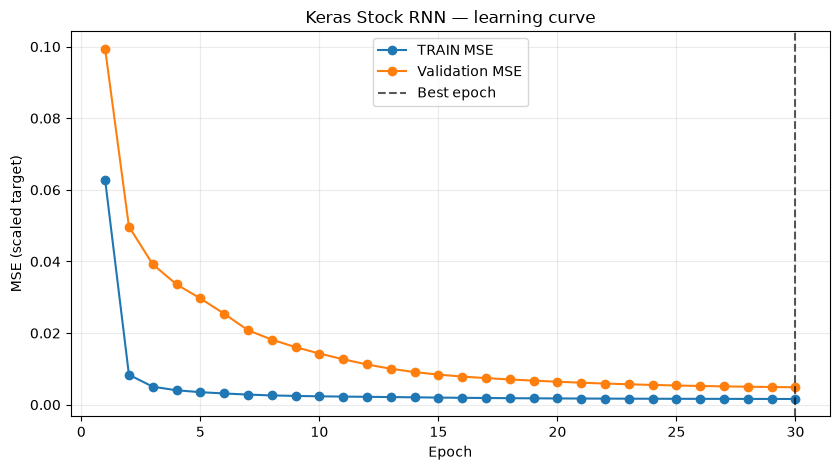

In [6]:
epochs = np.arange(1, epochs_actually_run + 1)
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(epochs, history.history["loss"], marker="o", label="TRAIN MSE")
ax.plot(epochs, history.history["val_loss"], marker="o", label="Validation MSE")
ax.axvline(best_epoch, color="black", linestyle="--", alpha=0.65, label="Best epoch")
ax.set(title="Keras Stock RNN — learning curve", xlabel="Epoch", ylabel="MSE (scaled target)")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
loss_figure_path = FIGURE_DIR / "training_validation_loss.png"
fig.savefig(loss_figure_path, dpi=160, bbox_inches="tight")
plt.show()

## 7. Prediction, inverse scaling và TEST một lần

`predict()` sinh target scaled. Prediction và nhãn scaled được inverse-transform bằng target scaler TRAIN-only trước khi tính metric:

- **MAE:** độ lớn sai số tuyệt đối trung bình, đơn vị USD.
- **RMSE:** căn của MSE, đơn vị USD và nhạy hơn với sai số lớn.
- **R²:** tỷ lệ biến thiên được giải thích so với mốc dự đoán trung bình; có thể âm.

Naive baseline dùng cùng đúng 410 mẫu TEST:

$$\widehat{Close}_{t+1}^{naive} = Close_t.$$

Một RNN không được xem là hữu ích chỉ vì sai số tuyệt đối có vẻ nhỏ; phải so trực tiếp với baseline persistence này.

In [7]:
test_scaled_prediction = model.predict(
    artifacts["test"]["X"], batch_size=BATCH_SIZE, verbose=0
).ravel()
test_actual = artifacts["test"]["y"].astype(np.float64)
test_true_restored = inverse_transform_targets(target_scaler, artifacts["test"]["y_scaled"])
test_prediction = inverse_transform_targets(target_scaler, test_scaled_prediction)
test_naive = artifacts["test"]["naive_last_close"].astype(np.float64)

np.testing.assert_allclose(test_true_restored, test_actual, rtol=1e-5, atol=1e-4)
rnn_metrics = regression_metrics(test_actual, test_prediction)
naive_metrics = regression_metrics(test_actual, test_naive)

pd.DataFrame(
    [
        {"Mô hình": "Keras Vanilla RNN", "MAE (USD)": rnn_metrics["mae"], "RMSE (USD)": rnn_metrics["rmse"], "R²": rnn_metrics["r2"]},
        {"Mô hình": "Naive: last Close", "MAE (USD)": naive_metrics["mae"], "RMSE (USD)": naive_metrics["rmse"], "R²": naive_metrics["r2"]},
    ]
).set_index("Mô hình").round(4)

,MAE (USD),RMSE (USD),R²
Mô hình,,,
Keras Vanilla RNN,23.1947,27.8703,-0.4347
Naive: last Close,2.6177,3.8789,0.9722


In [8]:
if rnn_metrics["rmse"] < naive_metrics["rmse"]:
    comparison_message = "Keras RNN có RMSE thấp hơn naive trên TEST trong lần chạy đã khóa này."
elif rnn_metrics["rmse"] > naive_metrics["rmse"]:
    comparison_message = "Naive có RMSE thấp hơn Keras RNN; không có bằng chứng để tuyên bố RNN tốt hơn baseline."
else:
    comparison_message = "Keras RNN và naive có RMSE bằng nhau trong độ chính xác số hiện tại."
print(comparison_message)

Naive có RMSE thấp hơn Keras RNN; không có bằng chứng để tuyên bố RNN tốt hơn baseline.


## 8. Lưu predictions và metadata thí nghiệm

CSV giữ một hàng cho mỗi ngày mục tiêu theo thứ tự thời gian và cùng schema với PyTorch. JSON ghi kiến trúc, training history, real-scale metrics, baseline metrics, target scaler và checksum nguồn để phép so sánh sau này có thể truy vết.

In [9]:
test_dates = pd.to_datetime(artifacts["test"]["target_date"].astype(str))
predictions = pd.DataFrame(
    {
        "target_date": test_dates.strftime("%Y-%m-%d"),
        "actual_close": test_actual,
        "predicted_close": test_prediction,
        "naive_close": test_naive,
    }
)
assert predictions["target_date"].is_monotonic_increasing
assert not predictions.isna().any().any()
predictions.to_csv(PREDICTIONS_PATH, index=False)

model_hash = sha256(MODEL_PATH)
predictions_hash = sha256(PREDICTIONS_PATH)
metrics_payload = {
    "task": pytorch_metrics["task"],
    "framework": "Keras",
    "framework_versions": {"tensorflow": tf.__version__, "keras": keras.__version__},
    "architecture": {
        "recurrent_layer": "keras.layers.SimpleRNN",
        "input_size": 5,
        "sequence_length": 30,
        "hidden_units": HIDDEN_UNITS,
        "num_layers": 1,
        "activation": "tanh",
        "head": "Dense(1, activation='linear')",
    },
    "parameter_count": parameter_count,
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "loss": "MSE on scaled target",
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "min_delta": MIN_DELTA,
    "restore_best_weights": True,
    "epochs": epochs_actually_run,
    "epochs_actually_run": epochs_actually_run,
    "best_epoch": best_epoch,
    "best_validation_loss": best_validation_loss,
    "best_validation_loss_space": "standardized target",
    "device": device_label.lower(),
    "training_duration_seconds": training_duration_seconds,
    "selection_scope": "validation loss only; TEST unused until final evaluation",
    "training_history": {
        "train_loss": [float(value) for value in history.history["loss"]],
        "validation_loss": [float(value) for value in history.history["val_loss"]],
    },
    "MAE": rnn_metrics["mae"],
    "RMSE": rnn_metrics["rmse"],
    "R2": rnn_metrics["r2"],
    "naive_MAE": naive_metrics["mae"],
    "naive_RMSE": naive_metrics["rmse"],
    "naive_R2": naive_metrics["r2"],
    "test_metrics_real_scale": rnn_metrics,
    "naive_test_metrics_real_scale": naive_metrics,
    "real_scale_units": {"mae": "USD", "rmse": "USD", "r2": "unitless"},
    "test_evaluation_count": 1,
    "test_samples": len(predictions),
    "target_date_range": {"min": predictions["target_date"].iloc[0], "max": predictions["target_date"].iloc[-1]},
    "target_scaling": {
        "type": type(target_scaler).__name__,
        "fit_scope": target_scaler_info["fit_scope"],
        "path": target_scaler_info["path"],
        "sha256": target_scaler_info["sha256"],
        "inverse_transformed_for_final_metrics": True,
    },
    "input_artifact_sha256": artifact_hashes,
    "model": {"path": str(MODEL_PATH.relative_to(ROOT)).replace("\\", "/"), "sha256": model_hash},
    "predictions": {"path": str(PREDICTIONS_PATH.relative_to(ROOT)).replace("\\", "/"), "rows": len(predictions), "sha256": predictions_hash},
    "comparison": comparison_message,
}
METRICS_PATH.write_text(json.dumps(metrics_payload, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Đã lưu model -> {MODEL_PATH.relative_to(ROOT)}")
print(f"Đã lưu {len(predictions):,} predictions -> {PREDICTIONS_PATH.relative_to(ROOT)}")
print(f"Đã lưu metrics -> {METRICS_PATH.relative_to(ROOT)}")
predictions.head()

Đã lưu model -> models\keras\keras_stock_rnn_best.keras
Đã lưu 410 predictions -> results\predictions\keras_stock_predictions.csv
Đã lưu metrics -> results\metrics\keras_stock_metrics.json


,target_date,actual_close,predicted_close,naive_close
0,2024-05-14,187.429993,184.138525,186.279999
1,2024-05-15,189.720001,184.446649,187.429993
2,2024-05-16,189.839996,185.944296,189.720001
3,2024-05-17,189.869995,186.593139,189.839996
4,2024-05-20,191.039993,186.428741,189.869995


## 9. Actual và predicted theo thời gian

Các đường được vẽ theo `target_date` tăng dần trên cùng thang USD. Cả Keras RNN và naive đều dùng cùng target; biểu đồ không xáo trộn thời gian và không hàm ý khả năng sinh lời.

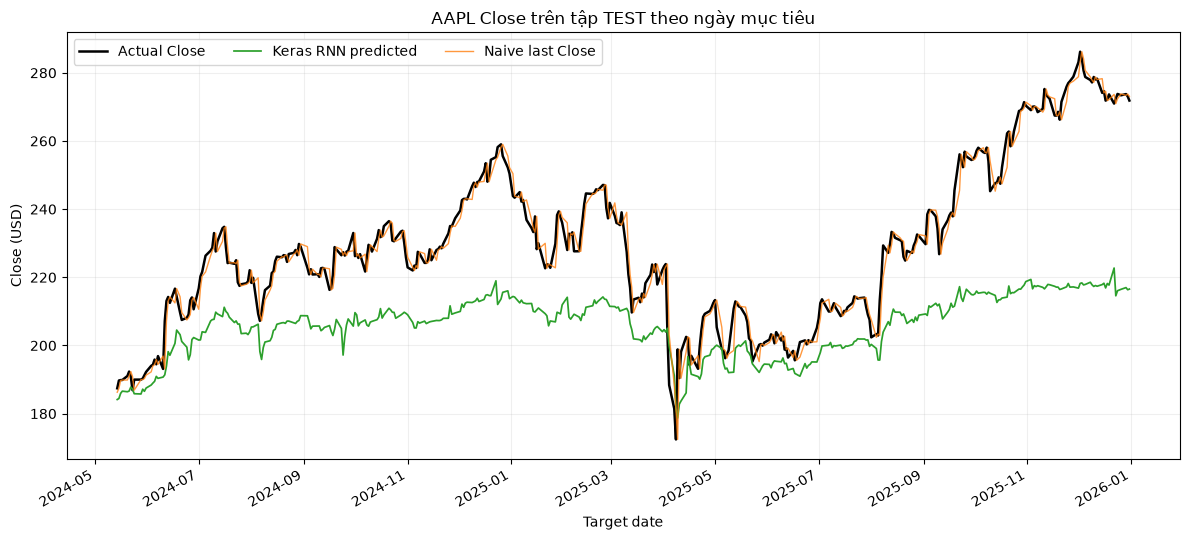

In [10]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(test_dates, test_actual, color="black", linewidth=1.8, label="Actual Close")
ax.plot(test_dates, test_prediction, color="#2ca02c", linewidth=1.25, label="Keras RNN predicted")
ax.plot(test_dates, test_naive, color="#ff7f0e", linewidth=1.0, alpha=0.8, label="Naive last Close")
ax.set(title="AAPL Close trên tập TEST theo ngày mục tiêu", xlabel="Target date", ylabel="Close (USD)")
ax.grid(alpha=0.2)
ax.legend(ncol=3)
fig.autofmt_xdate()
fig.tight_layout()
prediction_figure_path = FIGURE_DIR / "test_actual_vs_predicted.png"
fig.savefig(prediction_figure_path, dpi=160, bbox_inches="tight")
plt.show()

## 10. So sánh Keras RNN với naive baseline

MAE và RMSE được đặt cùng panel vì đều có đơn vị USD; R² nằm ở panel riêng vì không có đơn vị. Biểu đồ chỉ phản ánh 410 mẫu TEST đã khóa và không phải đánh giá đầu tư.

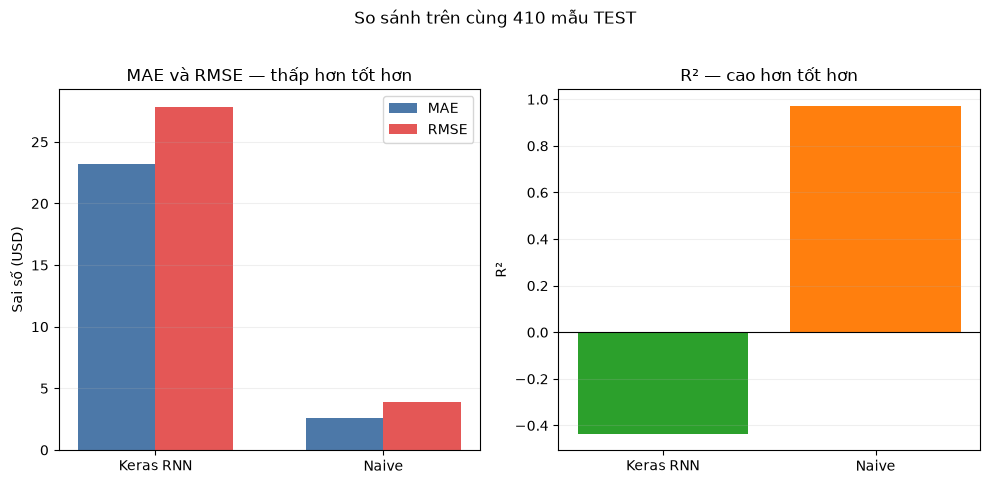

In [11]:
labels = ["Keras RNN", "Naive"]
colors = ["#2ca02c", "#ff7f0e"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.7))

x = np.arange(2)
width = 0.34
axes[0].bar(x - width / 2, [rnn_metrics["mae"], naive_metrics["mae"]], width, label="MAE", color="#4c78a8")
axes[0].bar(x + width / 2, [rnn_metrics["rmse"], naive_metrics["rmse"]], width, label="RMSE", color="#e45756")
axes[0].set_xticks(x, labels)
axes[0].set_ylabel("Sai số (USD)")
axes[0].set_title("MAE và RMSE — thấp hơn tốt hơn")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.2)

axes[1].bar(labels, [rnn_metrics["r2"], naive_metrics["r2"]], color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("R²")
axes[1].set_title("R² — cao hơn tốt hơn")
axes[1].grid(axis="y", alpha=0.2)

fig.suptitle("So sánh trên cùng 410 mẫu TEST", y=1.02)
fig.tight_layout()
comparison_figure_path = FIGURE_DIR / "rnn_vs_naive_metrics.png"
fig.savefig(comparison_figure_path, dpi=160, bbox_inches="tight")
plt.show()

## 11. Kiểm tra artifact đầu ra

Kiểm tra cuối xác nhận model nạp lại được, CSV đúng schema và thời gian, JSON có đủ metric, figures tồn tại, và checksum toàn bộ input/scaler vẫn giữ nguyên.

In [12]:
expected_columns = ["target_date", "actual_close", "predicted_close", "naive_close"]
assert MODEL_PATH.is_file()
assert METRICS_PATH.is_file()
assert PREDICTIONS_PATH.is_file()
assert predictions.columns.tolist() == expected_columns
assert len(predictions) == len(artifacts["test"]["y"]) == 410
assert pd.to_datetime(predictions["target_date"]).is_monotonic_increasing
assert not predictions["target_date"].duplicated().any()
assert all(path.is_file() for path in (loss_figure_path, prediction_figure_path, comparison_figure_path))

reloaded = keras.models.load_model(MODEL_PATH)
assert reloaded.input_shape == (None, 30, 5)
assert reloaded.output_shape == (None, 1)
assert reloaded.count_params() == parameter_count

saved_metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
for key in ("MAE", "RMSE", "R2", "naive_MAE", "naive_RMSE", "naive_R2"):
    assert np.isfinite(saved_metrics[key])
for split, expected_hash in artifact_hashes.items():
    input_path = ROOT / stock_meta["artifacts"][split]["path"]
    assert sha256(input_path) == expected_hash
assert sha256(target_scaler_path) == target_scaler_info["sha256"]

print("PASS — notebook chạy đầy đủ, model/CSV/JSON/figures hợp lệ, input và scaler không đổi.")
print("Figures:", sorted(path.name for path in FIGURE_DIR.glob("*.png")))

PASS — notebook chạy đầy đủ, model/CSV/JSON/figures hợp lệ, input và scaler không đổi.
Figures: ['rnn_vs_naive_metrics.png', 'test_actual_vs_predicted.png', 'training_validation_loss.png']


## 12. Tóm tắt và giới hạn

- Keras dùng đúng input `(samples, 30, 5)`, target scaled, split và scaler của PyTorch.
- `SimpleRNN(64)` tạo hidden state cuối; `Dense(1)` tuyến tính tạo prediction regression.
- MSE huấn luyện nằm trong scaled space; MAE/RMSE chỉ mang đơn vị USD sau inverse scaling.
- Validation loss quyết định early stopping và model checkpoint; TEST chỉ được dự đoán một lần sau lựa chọn mô hình.
- Naive last-Close là mốc bắt buộc. Kết luận RNN tốt hơn hay kém hơn phải dựa trên metric thực tế, không dựa vào độ phức tạp.
- Giá cổ phiếu chịu ảnh hưởng bởi thông tin và thay đổi chế độ thị trường không được mô tả đầy đủ bởi 30 ngày OHLCV. Kết quả của một split lịch sử không bảo đảm hiệu quả trong tương lai.

Notebook này **không đưa ra khuyến nghị tài chính**. So sánh tổng hợp PyTorch–Keras được dành cho Notebook 08.